In [5]:
# %% Block 1: Import
import torch
import torch.nn as nn
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import os
import glob

# Config phải khớp với train_pytorch.py
DATA_DIR = "dataset_processed"
SEQ_LEN = 30
INPUT_DIM = 63
HIDDEN_SIZE = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# %% Block 2: Load Model & Data
# Load Class Names
with open("../model_meta.json", "r") as f:
    meta = json.load(f)
    class_names = meta["labels"]

# Load Data (Test Set)
def load_data():
    X, y = [], []
    label_map = {lb: i for i, lb in enumerate(class_names)}
    for lb in class_names:
        files = glob.glob(os.path.join(DATA_DIR, lb, "*.npy"))
        for f in files:
            X.append(np.load(f))
            y.append(label_map[lb])
    return np.array(X), np.array(y)

X, y = load_data()
# Chia giống hệt lúc train để lấy tập Test
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Định nghĩa lại Model để load weight
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = GRUModel(INPUT_DIM, HIDDEN_SIZE, len(class_names)).to(DEVICE)
model.load_state_dict(torch.load("sign_model_augment.pth"))
model.eval()

# %% Block 3: Plot Training History
# Load history
if os.path.exists("training_history.json"):
    with open("training_history.json", "r") as f:
        history = json.load(f)

    epochs = range(1, len(history['loss']) + 1)

    plt.figure(figsize=(14, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['loss'], 'b-', label='Train Loss')
    plt.plot(epochs, history['val_loss'], 'r--', label='Val Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['acc'], 'b-', label='Train Acc')
    plt.plot(epochs, history['val_acc'], 'r--', label='Val Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy file history!")

# %% Block 4: Confusion Matrix & Metrics
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(DEVICE)

with torch.no_grad():
    outputs = model(X_test_tensor)
    _, preds = torch.max(outputs, 1)

preds = preds.cpu().numpy()
y_true = y_test_tensor.cpu().numpy()

# 1. Classification Report
print("--- Classification Report ---")
print(classification_report(y_true, preds, target_names=class_names))

# 2. Confusion Matrix
cm = confusion_matrix(y_true, preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../model_meta.json'

✅ Load model weights thành công!


/tmp/ipykernel_81906/2920491116.py:66: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


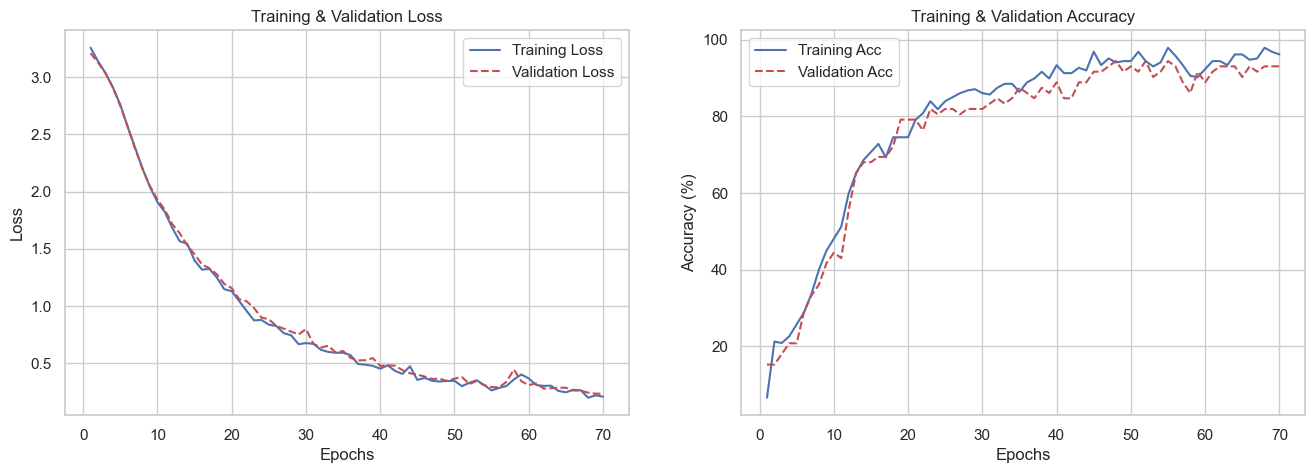

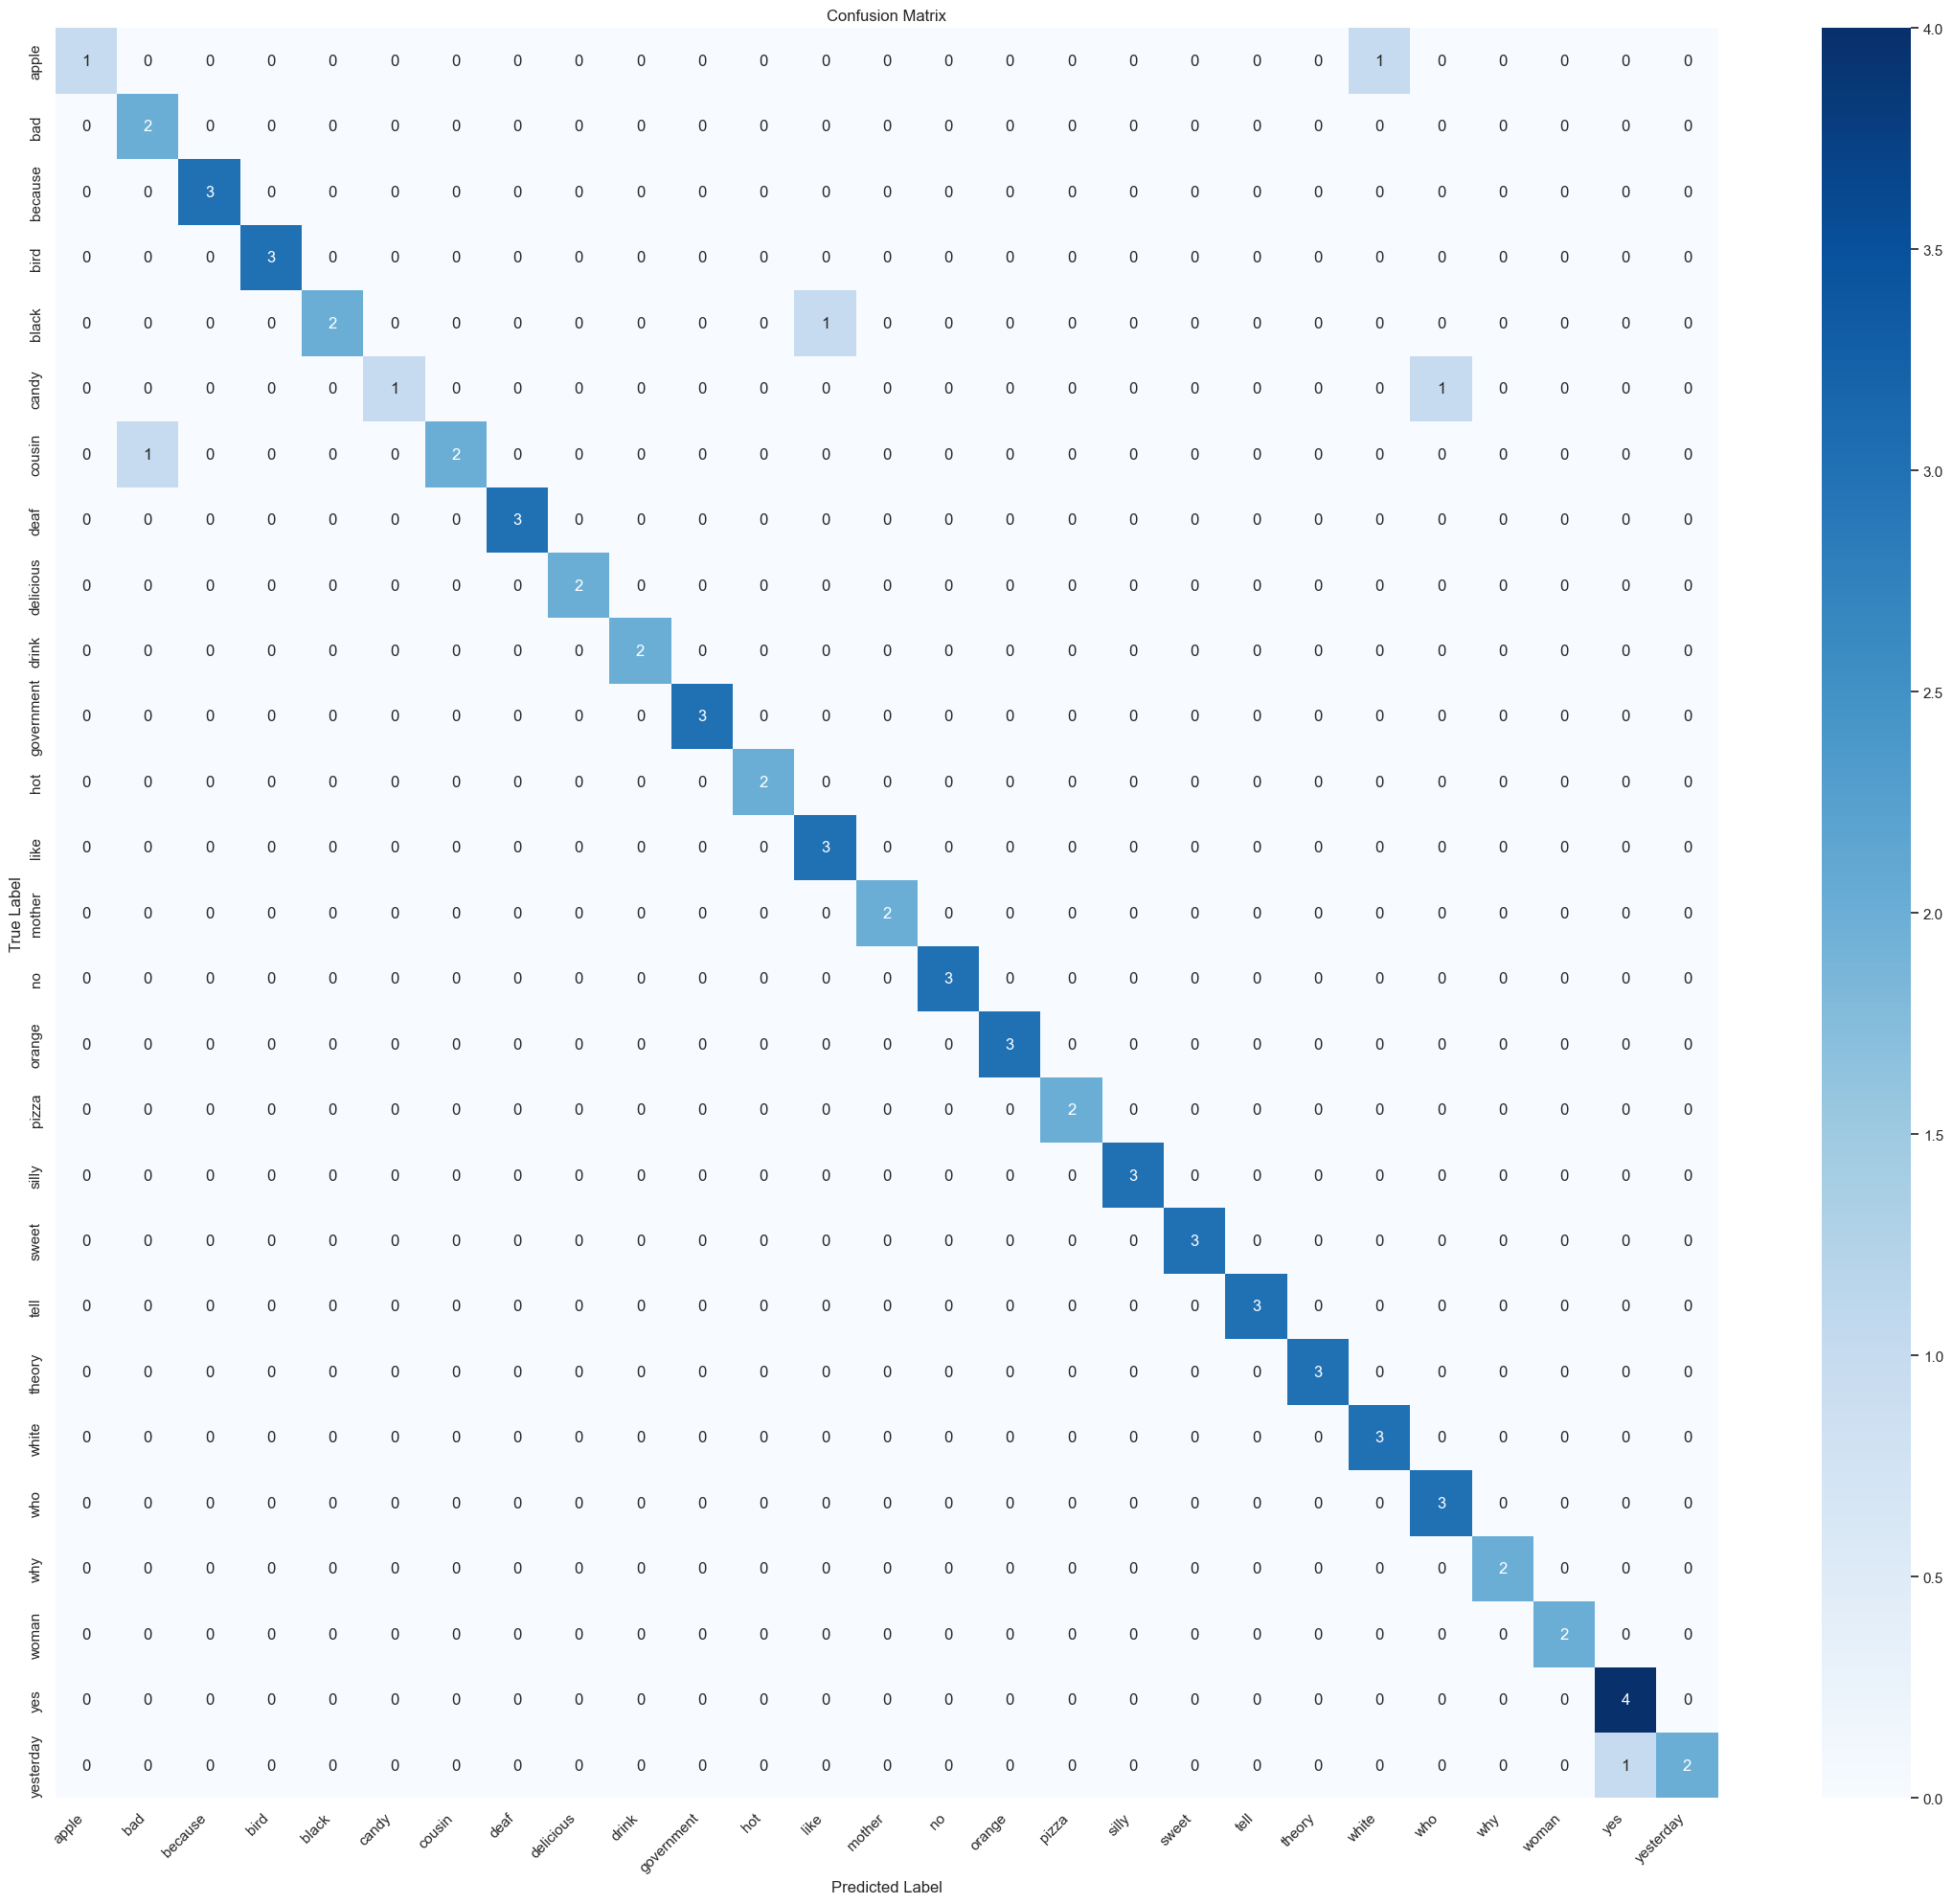

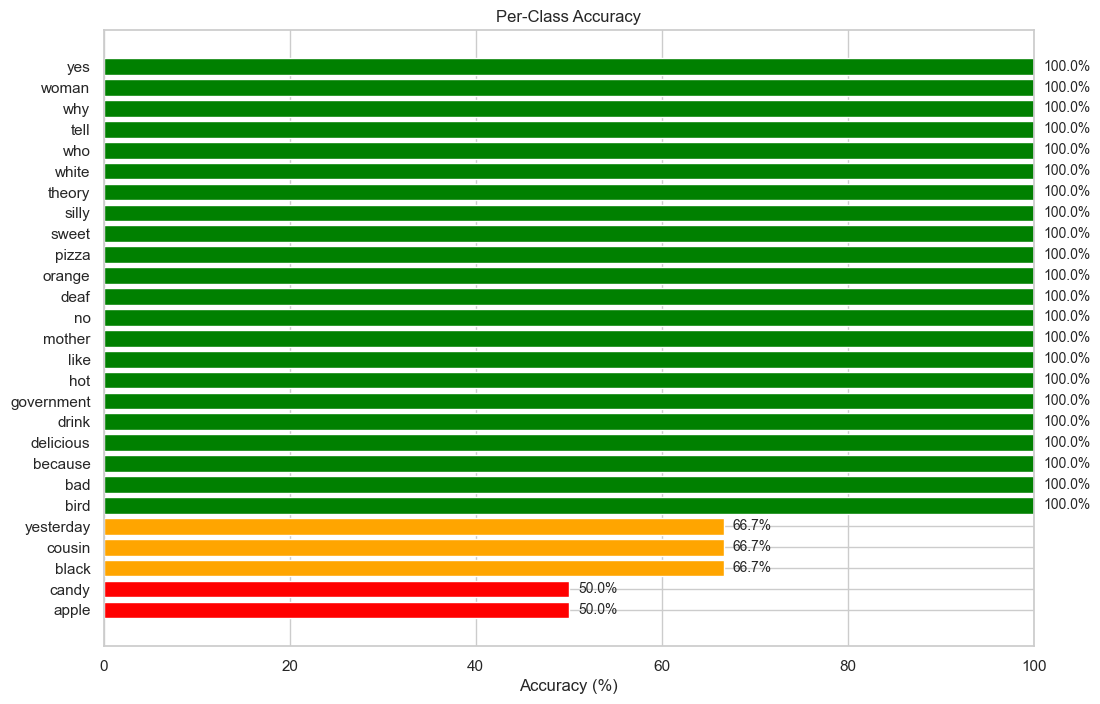


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       apple       1.00      0.50      0.67         2
         bad       0.67      1.00      0.80         2
     because       1.00      1.00      1.00         3
        bird       1.00      1.00      1.00         3
       black       1.00      0.67      0.80         3
       candy       1.00      0.50      0.67         2
      cousin       1.00      0.67      0.80         3
        deaf       1.00      1.00      1.00         3
   delicious       1.00      1.00      1.00         2
       drink       1.00      1.00      1.00         2
  government       1.00      1.00      1.00         3
         hot       1.00      1.00      1.00         2
        like       0.75      1.00      0.86         3
      mother       1.00      1.00      1.00         2
          no       1.00      1.00      1.00         3
      orange       1.00      1.00      1.00         3
       pizza       1.00      1.00      1.00       

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import os
import glob
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# --- CẤU HÌNH ---
RANDOM_SEED = 42
DATA_DIR = "../data/dataset_processed"
MODEL_DIR = "../models"  # Thư mục chứa model và history
MODEL_PATH = os.path.join(MODEL_DIR, "sign_model_augment.pth")
HISTORY_PATH = os.path.join(MODEL_DIR, "training_history.json")
INPUT_DIM = 63
HIDDEN_SIZE = 64

# --- CLASS MODEL ---
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

# --- LOAD DATA ---
def load_data():
    X, y = [], []
    if not os.path.exists(DATA_DIR):
        print(f"❌ Error: Không tìm thấy {DATA_DIR}")
        return None, None, None

    labels = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    label_map = {lb: i for i, lb in enumerate(labels)}

    for lb in labels:
        files = glob.glob(os.path.join(DATA_DIR, lb, "*.npy"))
        for f in files:
            data = np.load(f)
            if data.shape == (30, 63):
                X.append(data)
                y.append(label_map[lb])
    return np.array(X), np.array(y), labels

# --- MAIN ---

# 1. Load Data & Split
X, y, class_names = load_data()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 2. Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRUModel(INPUT_DIM, HIDDEN_SIZE, len(class_names)).to(device)
try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("✅ Load model weights thành công!")
except:
    print("❌ Không tìm thấy file weights .pth")

# 3. Inference
model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)

y_true = y_test_tensor.cpu().numpy()
y_pred = predicted.cpu().numpy()

# =================================================================
# PHẦN VẼ BIỂU ĐỒ (VISUALIZATION)
# =================================================================
sns.set(style='whitegrid')

# BIỂU ĐỒ 1: LEARNING CURVES (LOSS & ACCURACY)
# Load history từ file json
if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH, "r") as f:
        history = json.load(f)

    epochs = range(1, len(history['loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Loss Chart
    ax1.plot(epochs, history['loss'], 'b-', label='Training Loss')
    ax1.plot(epochs, history['val_loss'], 'r--', label='Validation Loss')
    ax1.set_title('Training & Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()

    # Accuracy Chart
    ax2.plot(epochs, history['acc'], 'b-', label='Training Acc')
    ax2.plot(epochs, history['val_acc'], 'r--', label='Validation Acc')
    ax2.set_title('Training & Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()

    plt.show()
else:
    print("⚠️ Không tìm thấy file training_history.json, bỏ qua vẽ Learning Curves.")

# BIỂU ĐỒ 2: CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(28, 24))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

# BIỂU ĐỒ 3: ĐỘ CHÍNH XÁC TỪNG CLASS (PER-CLASS ACCURACY)
# Tính accuracy cho từng class: (Số lần đoán đúng class i) / (Tổng số mẫu thực tế class i)
class_acc = cm.diagonal() / cm.sum(axis=1)

# Sắp xếp để dễ nhìn (từ thấp đến cao)
sorted_indices = np.argsort(class_acc)
sorted_names = [class_names[i] for i in sorted_indices]
sorted_scores = class_acc[sorted_indices] * 100

plt.figure(figsize=(12, 8))
colors = ['red' if x < 60 else 'orange' if x < 80 else 'green' for x in sorted_scores]
bars = plt.barh(sorted_names, sorted_scores, color=colors)

plt.xlabel('Accuracy (%)')
plt.title('Per-Class Accuracy')
plt.xlim(0, 100)

# Thêm số % vào đuôi cột
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontsize=10)

plt.show()

# REPORT CHI TIẾT DẠNG TEXT
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names))

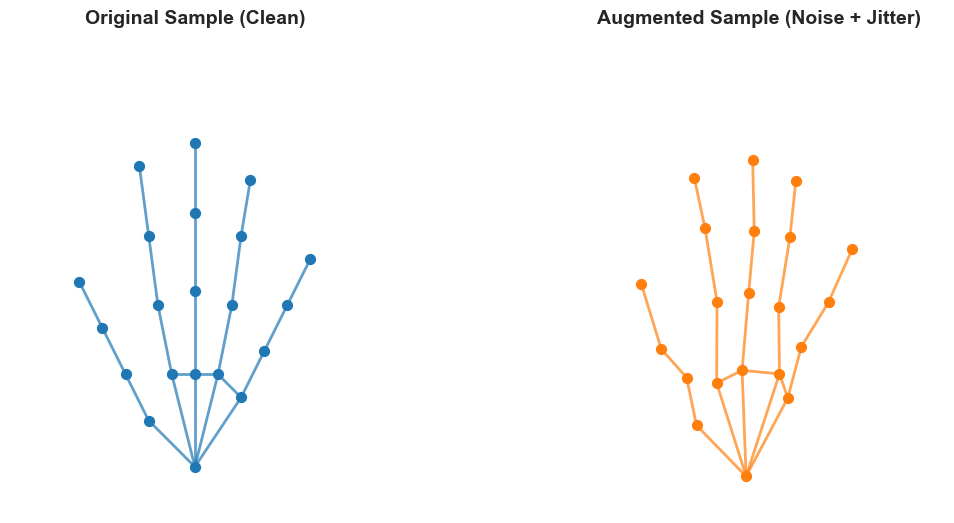

✅ Đã xuất file ảnh: augmentation_visualization.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import random

# --- 1. CẤU HÌNH DỮ LIỆU GIẢ LẬP (MOCK DATA) ---
# Vì tôi không có file .npy của bạn, tôi sẽ tạo ra một bàn tay chuẩn (Original)
# Dựa trên cấu trúc bàn tay 21 điểm của MediaPipe
def create_dummy_hand():
    # Tọa độ cơ bản của một bàn tay xòe ra (2D projection)
    # 0: Wrist
    # 1-4: Thumb, 5-8: Index, 9-12: Middle, 13-16: Ring, 17-20: Pinky
    hand = np.array([
        [0.5, 0.1],   # 0. Wrist
        [0.4, 0.2], [0.35, 0.3], [0.3, 0.4], [0.25, 0.5], # Thumb
        [0.45, 0.3], [0.42, 0.45], [0.4, 0.6], [0.38, 0.75], # Index
        [0.5, 0.3], [0.5, 0.48], [0.5, 0.65], [0.5, 0.8],   # Middle
        [0.55, 0.3], [0.58, 0.45], [0.6, 0.6], [0.62, 0.72], # Ring
        [0.6, 0.25], [0.65, 0.35], [0.7, 0.45], [0.75, 0.55] # Pinky
    ])
    # Thêm chiều Z giả (flat) để đúng format (21, 3) nếu cần, ở đây vẽ 2D cho dễ nhìn
    return hand

# Các đường nối đốt ngón tay (MediaPipe Connections)
HAND_CONNECTIONS = [
    (0, 1), (1, 2), (2, 3), (3, 4),           # Thumb
    (0, 5), (5, 6), (6, 7), (7, 8),           # Index
    (0, 9), (9, 10), (10, 11), (11, 12),      # Middle
    (0, 13), (13, 14), (14, 15), (15, 16),    # Ring
    (0, 17), (17, 18), (18, 19), (19, 20),    # Pinky
    (5, 9), (9, 13), (13, 17)                 # Palm
]

# --- 2. HÀM AUGMENTATION (Mô phỏng logic trong train_pytorch.py) ---
def apply_visual_augmentation(data):
    """
    Áp dụng nhiễu để hiển thị sự khác biệt
    """
    data_aug = data.copy()

    # A. Gaussian Noise (Thêm nhiễu ngẫu nhiên)
    noise = np.random.normal(0, 0.015, data_aug.shape) # Std=0.015 để thấy rõ nhiễu
    data_aug += noise

    # B. Scaling/Shear (Mô phỏng tay bị nghiêng/co giãn)
    # Scale ngẫu nhiên X và Y
    scale_x = random.uniform(0.9, 1.1)
    scale_y = random.uniform(0.9, 1.1)
    data_aug[:, 0] *= scale_x
    data_aug[:, 1] *= scale_y

    return data_aug

# --- 3. VẼ BIỂU ĐỒ ---
def plot_comparison():
    # Tạo dữ liệu
    original_hand = create_dummy_hand()
    augmented_hand = apply_visual_augmentation(original_hand)

    # Setup Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Màu sắc
    color_orig = '#1f77b4' # Xanh dương
    color_aug = '#ff7f0e'  # Cam

    titles = ["Original Sample (Clean)", "Augmented Sample (Noise + Jitter)"]
    hands_data = [original_hand, augmented_hand]
    colors = [color_orig, color_aug]

    for i, ax in enumerate(axes):
        hand = hands_data[i]
        c = colors[i]

        # Vẽ các điểm (Joints)
        ax.scatter(hand[:, 0], hand[:, 1], c=c, s=50, zorder=5)

        # Vẽ các đường nối (Bones)
        for connection in HAND_CONNECTIONS:
            start_idx, end_idx = connection
            p1 = hand[start_idx]
            p2 = hand[end_idx]
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]], c=c, linewidth=2, alpha=0.7)

        # Cấu hình trục (Tắt khung để nhìn giống report khoa học)
        ax.set_title(titles[i], fontsize=14, pad=20, fontweight='bold')
        ax.set_xlim(0.1, 0.9)
        ax.set_ylim(0, 1.0)
        ax.set_aspect('equal')
        ax.axis('off') # Tắt trục tọa độ cho đẹp

        # Vẽ khung bao quanh (Tùy chọn)
        # ax.add_patch(plt.Rectangle((0.1, 0), 0.8, 1.0, fill=False, edgecolor='gray', lw=1))

    # Thêm Caption phía dưới


    plt.tight_layout(rect=[0, 0.1, 1, 1]) # Chừa chỗ cho caption

    # Lưu ảnh hoặc hiển thị
    plt.savefig("augmentation_visualization.png", dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Đã xuất file ảnh: augmentation_visualization.png")

if __name__ == "__main__":
    plot_comparison()

📂 Đang load data từ: /home/dangkhoi/dev/Projects/AR-drawing/data/dataset_processed
✅ Load xong 655 mẫu.
🔄 Đang load weights từ: /home/dangkhoi/dev/Projects/AR-drawing/models/sign_model_augment.pth
✅ Load model weights thành công!


/tmp/ipykernel_7355/1789930867.py:81: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=device))


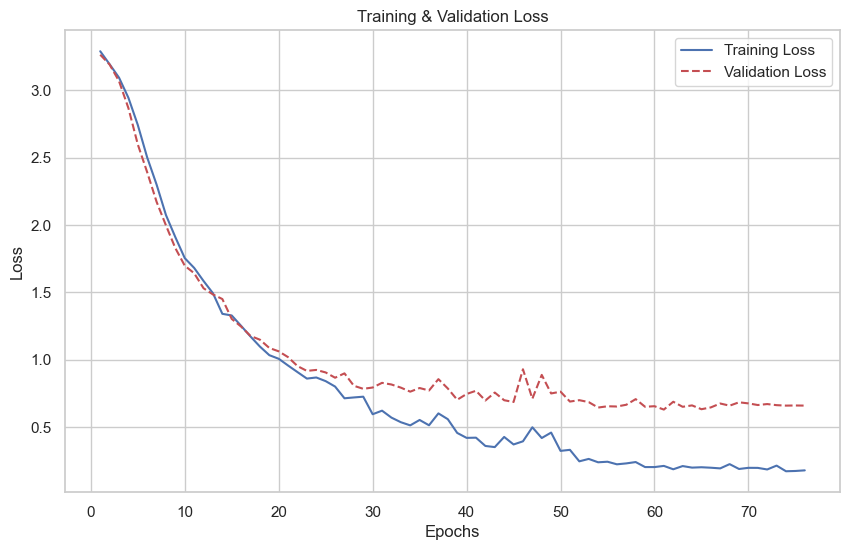

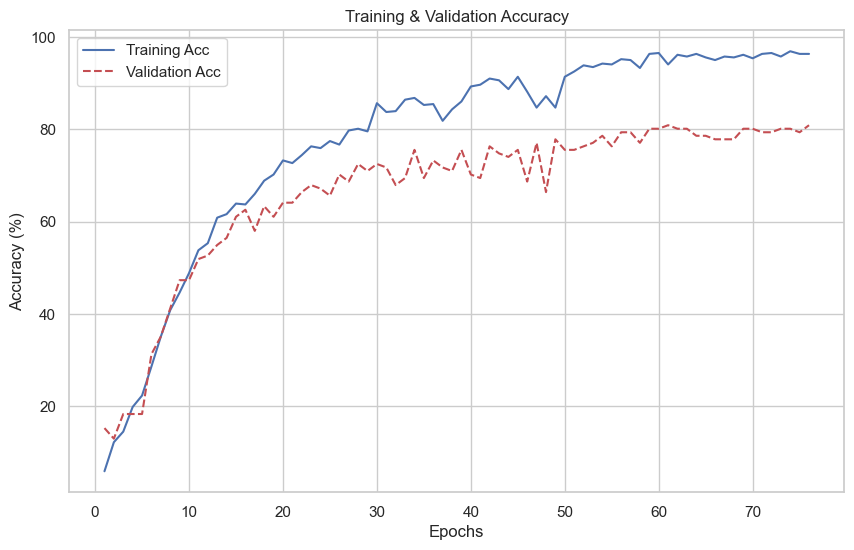

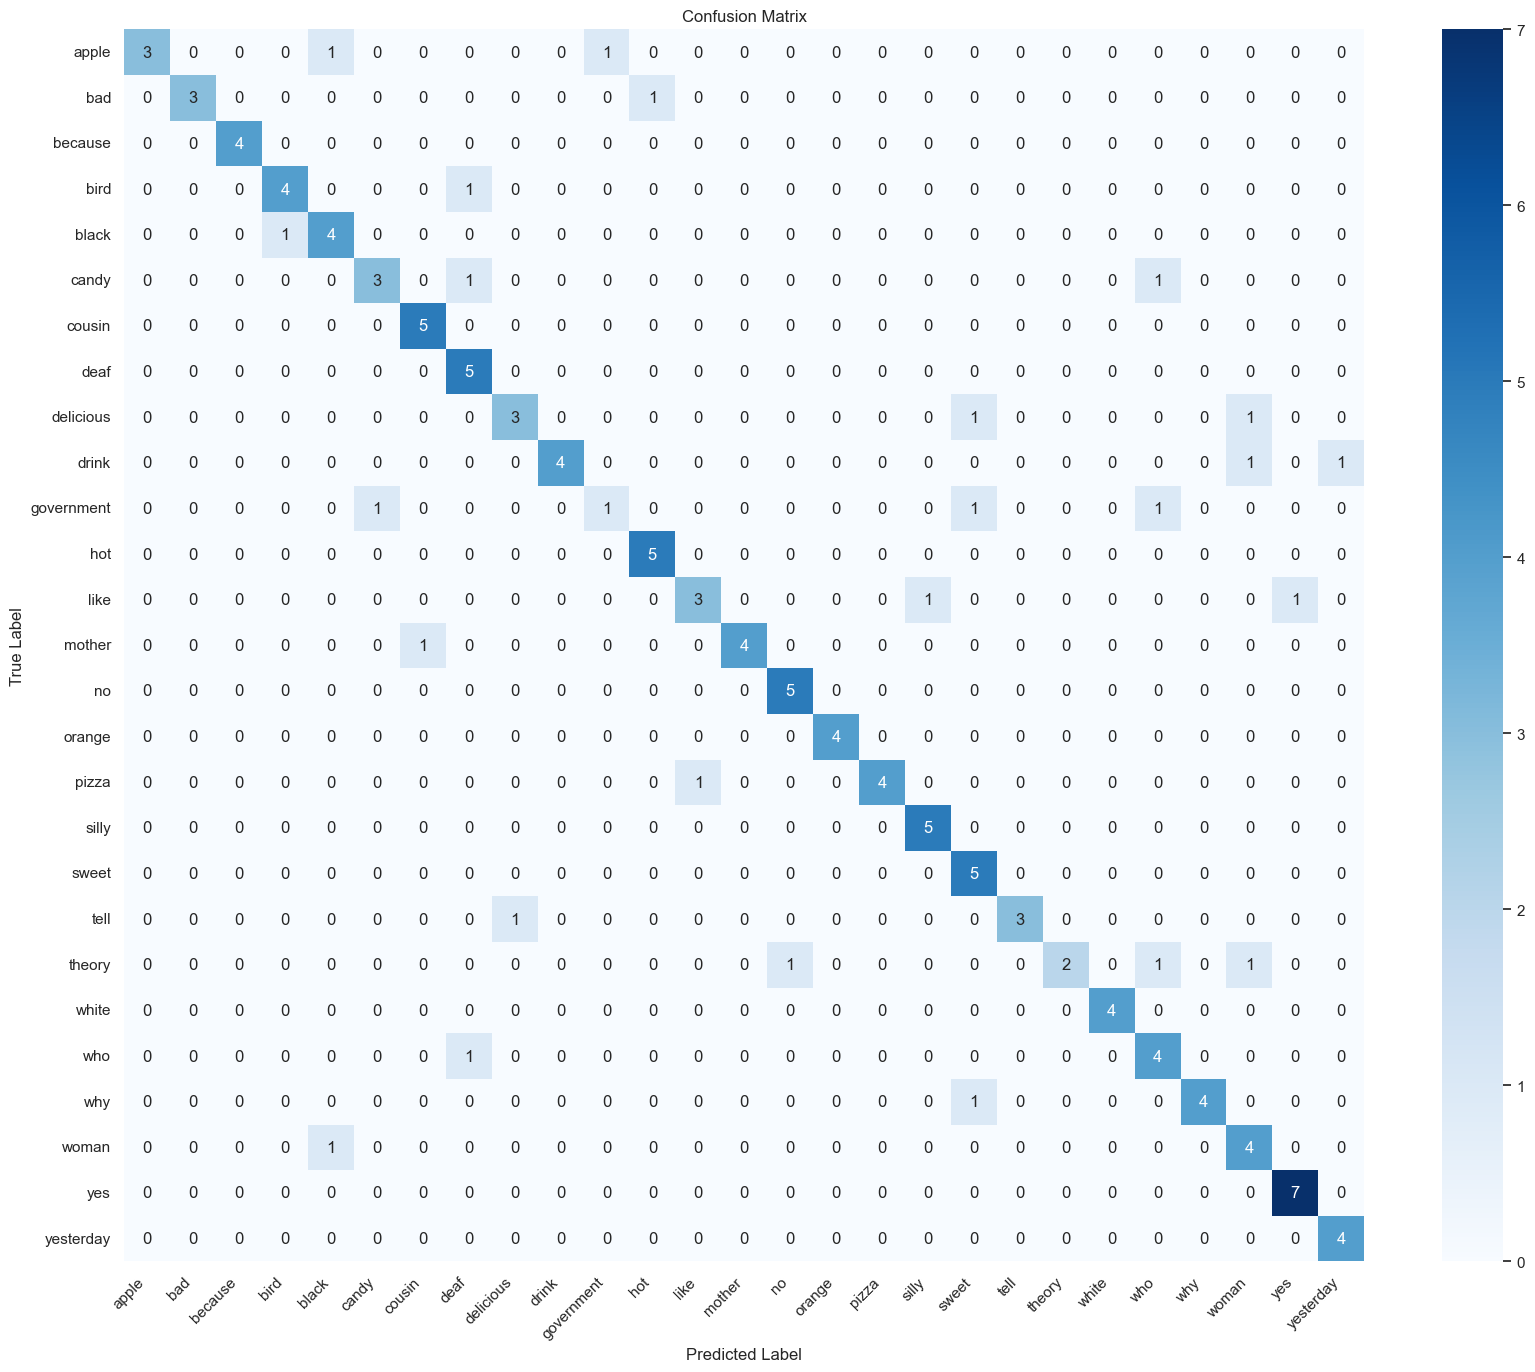

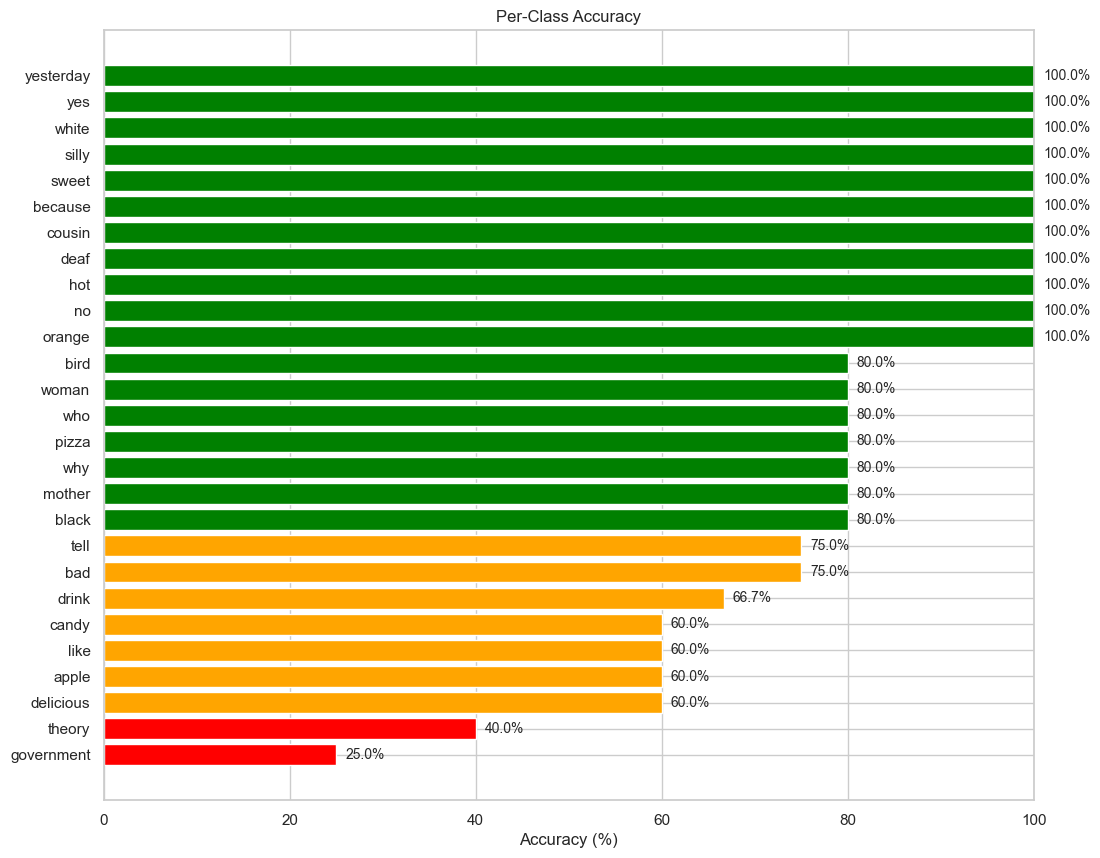


--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       apple       1.00      0.60      0.75         5
         bad       1.00      0.75      0.86         4
     because       1.00      1.00      1.00         4
        bird       0.80      0.80      0.80         5
       black       0.67      0.80      0.73         5
       candy       0.75      0.60      0.67         5
      cousin       0.83      1.00      0.91         5
        deaf       0.62      1.00      0.77         5
   delicious       0.75      0.60      0.67         5
       drink       1.00      0.67      0.80         6
  government       0.50      0.25      0.33         4
         hot       0.83      1.00      0.91         5
        like       0.75      0.60      0.67         5
      mother       1.00      0.80      0.89         5
          no       0.83      1.00      0.91         5
      orange       1.00      1.00      1.00         4
       pizza       1.00      0.80      0.89       

In [7]:
import torch
import torch.nn as nn
import numpy as np
import os
import glob
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# --- CẤU HÌNH ---
RANDOM_SEED = 42
# Dùng đường dẫn tuyệt đối cho chắc chắn
BASE_DIR = "/home/dangkhoi/dev/Projects/AR-drawing"
DATA_DIR = os.path.join(BASE_DIR, "data/dataset_processed")
MODEL_DIR = os.path.join(BASE_DIR, "models")
MODEL_PATH = os.path.join(MODEL_DIR, "sign_model_augment.pth")
HISTORY_PATH = os.path.join(MODEL_DIR, "training_history.json")

INPUT_DIM = 63
HIDDEN_SIZE = 64

# --- CLASS MODEL (PHẢI KHỚP 100% VỚI FILE TRAIN) ---
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(GRUModel, self).__init__()
        # CẬP NHẬT: Thêm num_layers=2 và dropout=0.3
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True, dropout=0.3, num_layers=2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.dropout(out) # Thêm dropout
        out = self.fc(out)
        return out

# --- LOAD DATA ---
def load_data():
    X, y = [], []
    if not os.path.exists(DATA_DIR):
        print(f"❌ Error: Không tìm thấy thư mục data tại {DATA_DIR}")
        return None, None, None

    labels = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
    label_map = {lb: i for i, lb in enumerate(labels)}

    print(f"📂 Đang load data từ: {DATA_DIR}")
    for lb in labels:
        files = glob.glob(os.path.join(DATA_DIR, lb, "*.npy"))
        for f in files:
            data = np.load(f)
            if data.shape == (30, 63):
                X.append(data)
                y.append(label_map[lb])

    print(f"✅ Load xong {len(X)} mẫu.")
    return np.array(X), np.array(y), labels

# --- MAIN ---

# 1. Load Data & Split
X, y, class_names = load_data()
if X is None or len(X) == 0:
    print("❌ Không có dữ liệu để chạy.")
    exit()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# 2. Load Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRUModel(INPUT_DIM, HIDDEN_SIZE, len(class_names)).to(device)

print(f"🔄 Đang load weights từ: {MODEL_PATH}")
try:
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print("✅ Load model weights thành công!")
except Exception as e:
    # In ra lỗi thực sự
    print(f"❌ Lỗi load model: {e}")
    print("👉 Gợi ý: Kiểm tra xem kiến trúc model trong file này (GRUModel) có giống hệt file train_pytorch.py không (num_layers, dropout...)")
    exit()

# 3. Inference
model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs, 1)

y_true = y_test_tensor.cpu().numpy()
y_pred = predicted.cpu().numpy()

# =================================================================
# PHẦN VẼ BIỂU ĐỒ
# =================================================================
sns.set(style='whitegrid')

# Load history
if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH, "r") as f:
        history = json.load(f)

    epochs = range(1, len(history['loss']) + 1)

    # HÌNH 1: LOSS
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history['loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r--', label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # HÌNH 2: ACCURACY
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, history['acc'], 'b-', label='Training Acc')
    plt.plot(epochs, history['val_acc'], 'r--', label='Validation Acc')
    plt.title('Training & Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()
else:
    print(f"⚠️ Không tìm thấy file history tại {HISTORY_PATH}")

# HÌNH 3: CONFUSION MATRIX
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(20, 16)) # Tăng kích thước hình
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.show()

# HÌNH 4: PER-CLASS ACCURACY
class_acc = cm.diagonal() / cm.sum(axis=1)
sorted_indices = np.argsort(class_acc)
sorted_names = [class_names[i] for i in sorted_indices]
sorted_scores = class_acc[sorted_indices] * 100

plt.figure(figsize=(12, 10))
colors = ['red' if x < 60 else 'orange' if x < 80 else 'green' for x in sorted_scores]
bars = plt.barh(sorted_names, sorted_scores, color=colors)
plt.xlabel('Accuracy (%)')
plt.title('Per-Class Accuracy')
plt.xlim(0, 100)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2,
             f'{width:.1f}%', va='center', fontsize=10)

plt.show()

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=class_names))